In [2]:
%load_ext autoreload
%autoreload 2

In [36]:
import numpy as np
import ase
import abtem
from pathlib import Path
import matplotlib.pyplot as plt
import os
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from PIL import Image
import skimage.filters as filters
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from skimage import measure

GPU_use = 0

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"  # con1sistent GPU ordering
os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU_use)
os.environ["OMP_NUM_THREADS"] = "1"

import cupy as cp

In [4]:
# !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
# wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth
# wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

In [62]:
# Class object for segmenting and outputting com
class Segmentor():
    """
    Class object for segmenting grayscale images.

    Input:
        model_type: default=None
            The type of micro-segment anything model used. Defaults to 'vit_b' if None.
        device: default=None
            The device for running the segmentation model. Best to provide device,
            but if None will attempt to use GPU.
    
    segment_image(potential):
        potential:
            The potential of the image to be segmented
        
        -> filtered_labeled_masks, com

        filtered_labeled_masks:
            An image containing the masks for each ROI.
            Each value in the mask corresponds to a different ROI.
            E.g. 1's in matrix will be mask for ROI 1, 3's will be mask for ROI 3, etc.
            0 corresponds to background / non-segmented region. Means 1-index is first ROI.
        
        com: List
            A list of the CoM coordinates for each region. Provided in row (y), col (x) format.
            Skips background / non-segmented region, so 0 corresponds to first ROI.
    """

    def __init__(self, model_type=None, device=None):
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        if model_type is None:
            model_type = "vit_b"
        self.device = device
        self.model_type = model_type
        # Load SAM model
        sam = sam_model_registry[model_type](checkpoint=None)
        sam.to(device=device)
        self.sam = sam
        self.mask_generator = None

    def normalize_image(self, potential):
        """ Normalizes image to 255 to be in line with RGB values for model input"""
        potential_normalized = potential.array/potential.array.sum(axis=0).max().compute() * 255  # Normalize to 0-255
        potential_normalized = potential_normalized.sum(axis=0).compute().get()
        return potential_normalized

    def enhance_contrast(self, image):
        """Enhances contrast to better define boundaries for segmentation when passed to model"""
        image_enhanced = (image - image.min()) / (image.max() - image.min())
        image_enhanced = (image_enhanced * 255).astype(np.uint8)
        return image_enhanced

    def create_mask_generator(
        self,
        points_per_side=32,
        pred_iou_thresh=0.9,
        stability_score_thresh=0.85, 
        crop_n_layers=1,
        crop_n_points_downscale_factor=2,
        min_mask_region_area=50, 
        output_mode='binary_mask',
        ):
        # Create mask generator with adjusted parameters
        mask_generator = SamAutomaticMaskGenerator(
            model=self.sam,
            points_per_side=points_per_side,
            pred_iou_thresh=pred_iou_thresh,
            stability_score_thresh=stability_score_thresh,
            crop_n_layers=crop_n_layers,
            crop_n_points_downscale_factor=crop_n_points_downscale_factor,
            min_mask_region_area=min_mask_region_area,
            output_mode=output_mode,
        )
        self.mask_generator = mask_generator

    def show_masks(self, image, masks):
            if len(masks) == 0:
                print("No masks found!")
                return
            
            sorted_masks = sorted(masks, key=lambda x: x['area'], reverse=True)
            
            fig, axes = plt.subplots(1, 2, figsize=(16, 8))
            
            axes[0].imshow(image[:, :, 0], cmap='viridis')
            axes[0].set_title('Original Potential')
            axes[0].axis('off')
            
            axes[1].imshow(image[:, :, 0], cmap='gray', alpha=0.7)
            
            overlay = np.zeros((*image.shape[:2], 4))
            for i, mask_data in enumerate(sorted_masks):
                mask = mask_data['segmentation']
                color = np.concatenate([np.random.random(3), [0.6]])
                overlay[mask] = color
            
            axes[1].imshow(overlay)
            axes[1].set_title(f'Segmentation ({len(masks)} masks)')
            axes[1].axis('off')
            
            plt.tight_layout()
            plt.show()

    def label_and_filter_masks(self, masks, min_area=100, show_plots=True):
        def combine_masks(masks):
            if not masks:
                return None
            combined = np.zeros_like(masks[0]['segmentation'], dtype=bool)
            for mask in masks:
                combined |= mask['segmentation']
            return combined

        def label_mask(mask):
            binary_mask = mask.astype(bool)
            labeled_mask = measure.label(binary_mask, connectivity=2)
            num_features = labeled_mask.max()
            if show_plots:
                print(f"Number of labeled features: {num_features}")
            return labeled_mask

        def remove_small_labels(labeled_mask, min_area):
            props = measure.regionprops(labeled_mask)
            filtered_mask = np.zeros_like(labeled_mask)
            for prop in props:
                if prop.area >= min_area:
                    filtered_mask[labeled_mask == prop.label] = prop.label
            new_labeled_mask = measure.label(filtered_mask > 0)
            num_features = new_labeled_mask.max()
            if show_plots:
                print(f"Number of features after filtering: {num_features}")
            return new_labeled_mask

        # Combine all masks
        combined_mask = combine_masks(masks)

        if combined_mask is not None:
            # Label the combined mask
            labeled_mask = label_mask(combined_mask)
            # Remove small labels
            filtered_labeled_mask = remove_small_labels(labeled_mask, min_area)

            if show_plots:
                # Visualize
                fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 10))
                ax1.imshow(combined_mask, cmap='gray')
                ax1.set_title('Combined Mask')
                ax1.axis('off')

                ax2.imshow(labeled_mask, cmap='nipy_spectral')
                ax2.set_title('Original Labeled Mask')
                ax2.axis('off')

                im = ax3.imshow(filtered_labeled_mask, cmap='nipy_spectral')
                ax3.set_title(f'Filtered Labeled Mask (Areas >= {min_area})')
                ax3.axis('off')

                cbar = fig.colorbar(im, ax=ax3, shrink=0.7)
                cbar.set_label('Label')
                plt.tight_layout()
                plt.show()

            return filtered_labeled_mask
        else:
            print("No masks found!")
            return None

    def calc_com(self, proj_pot, labeled_mask, show_plots=True):
        com_list = []
        for i in range(np.max(labeled_mask)):
            if show_plots:
                plt.matshow(proj_pot * (labeled_mask == i))
                plt.title(f"Label {i}")
            if i != 0:
                com = measure.centroid(proj_pot * (labeled_mask == i))
                com_list.append(com)
                if show_plots:
                    print(com)  # com in format (row, col) or (y, x) with reference to top-left
                    plt.scatter(com[1], com[0], c='r')
        return com_list

    def segment_image(self, potential, min_area=10, show_plots=True):
        # Assuming potential_normalized is your original image
        potential_normalized = self.normalize_image(potential)
        # Apply Gaussian smoothing
        potential_normalized = filters.gaussian(potential_normalized, sigma=1)
        # Enhance contrast
        potential_enhanced = self.enhance_contrast(potential_normalized)
        # Convert to 3-channel image (SAM expects RGB)
        potential_rgb = np.stack([potential_enhanced] * 3, axis=-1)

        if show_plots:
            print(f"Image shape: {potential_rgb.shape}")
            print(f"Image dtype: {potential_rgb.dtype}")
            print(f"Image range: [{potential_rgb.min()}, {potential_rgb.max()}]")

        self.create_mask_generator()

        if show_plots:
            # Visualize the input image
            plt.figure(figsize=(10, 10))
            plt.imshow(potential_rgb[:,:,0], cmap='viridis')
            plt.title('Input Image')
            plt.colorbar()
            plt.show()

        # Generate masks
        if show_plots:
            print("Generating masks...")
        try:
            masks = self.mask_generator.generate(potential_rgb)
            if show_plots:
                print(f"Found {len(masks)} segments")
        except Exception as e:
            print(f"Error in mask generation: {e}")
            masks = []

        # If SAM fails, use simple thresholding
        if len(masks) == 0:
            print("SAM failed to generate masks. Using simple thresholding.")
            # Simple thresholding without skimage
            threshold = np.mean(potential_enhanced) + np.std(potential_enhanced)
            binary_mask = potential_enhanced > threshold
            masks = [{'segmentation': binary_mask, 'area': np.sum(binary_mask)}]
            if show_plots:
                self.show_masks(potential_rgb, masks)

        # Show individual largest masks (up to 6)
        sorted_masks = sorted(masks, key=lambda x: x['area'], reverse=True)

        if show_plots:
            num_masks = min(6, len(masks))
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            axes = axes.flatten()

            for idx, (ax, mask_data) in enumerate(zip(axes, sorted_masks[:num_masks])):
                ax.imshow(mask_data['segmentation'], cmap='gray')
                ax.set_title(f"Mask {idx+1} (area: {mask_data['area']})")
                ax.axis('off')

            for idx in range(num_masks, 6):
                axes[idx].axis('off')
                
            plt.tight_layout()
            plt.show()
    
        # Assuming 'masks' is your list of mask dictionaries from SAM
        filtered_labeled_mask = self.label_and_filter_masks(masks, min_area=min_area, show_plots=show_plots)

        if filtered_labeled_mask is not None:
            # You can now use filtered_labeled_mask for further analysis
            if show_plots:
                print("Filtered labeled mask shape:", filtered_labeled_mask.shape)
                print("Unique labels:", np.unique(filtered_labeled_mask))

            # Example: Get properties of the remaining regions
            props = measure.regionprops(filtered_labeled_mask)
            for prop in props:
                if show_plots:
                    print(f"Label: {prop.label}")
                    print(f"  Area: {prop.area}")
                    print(f"  Centroid: {prop.centroid}")
                    print(f"  Bounding box: {prop.bbox}")
                    print("---")

        # Calculate CoM
        proj_pot = potential.array.sum(axis = 0).compute().get()
        com_list = self.calc_com(proj_pot, filtered_labeled_mask, show_plots=show_plots)
        return filtered_labeled_mask, com_list
    

# Building ABTEM Potentials and Zooming/Cropping into ROIs
*Cedric Lim, 10/28/25*

- Each gold nanoparticle is rotated at different orientatons, and embedded at different z-heights into the carbon substrate.

In [5]:
# Loading ASE atoms

system = ase.io.read('../data/au_np_system.xyz')

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>)

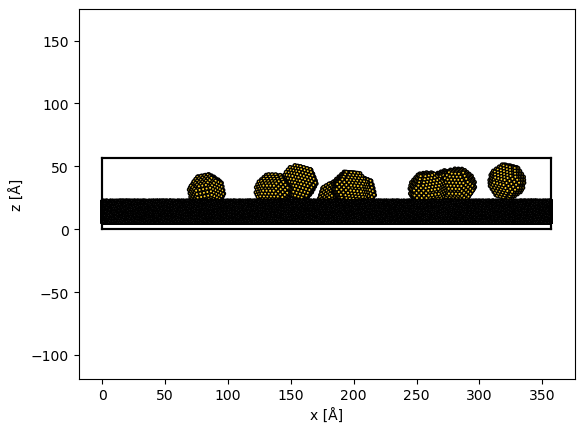

In [6]:
abtem.show_atoms(system, scale = 1, plane = 'xz')

# Building Potentials

In [7]:
potential?

Object `potential` not found.


[########################################] | 100% Completed | 949.49 ms
1836.9126


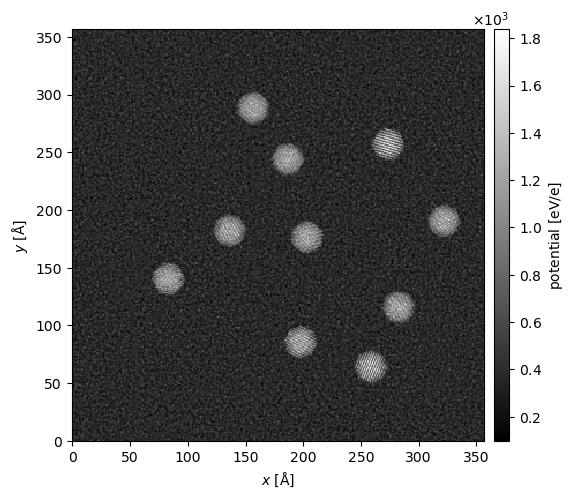

In [ ]:
# Multislice simulation to build potential
potential = abtem.Potential(
    system,
    sampling = 1,
    projection = 'infinite',
    slice_thickness = 1,
    # gpts = [100,100],
    device = 'gpu'
).build()

potential.show(cbar = True, cmap = 'gray')
print(potential.array.sum(axis=0).max().compute())
potential_normalized = potential.array/potential.array.sum(axis=0).max().compute() * 255  # Normalize to 0-255
proj_potential_normalized = potential_normalized.sum(axis=0).compute().get()

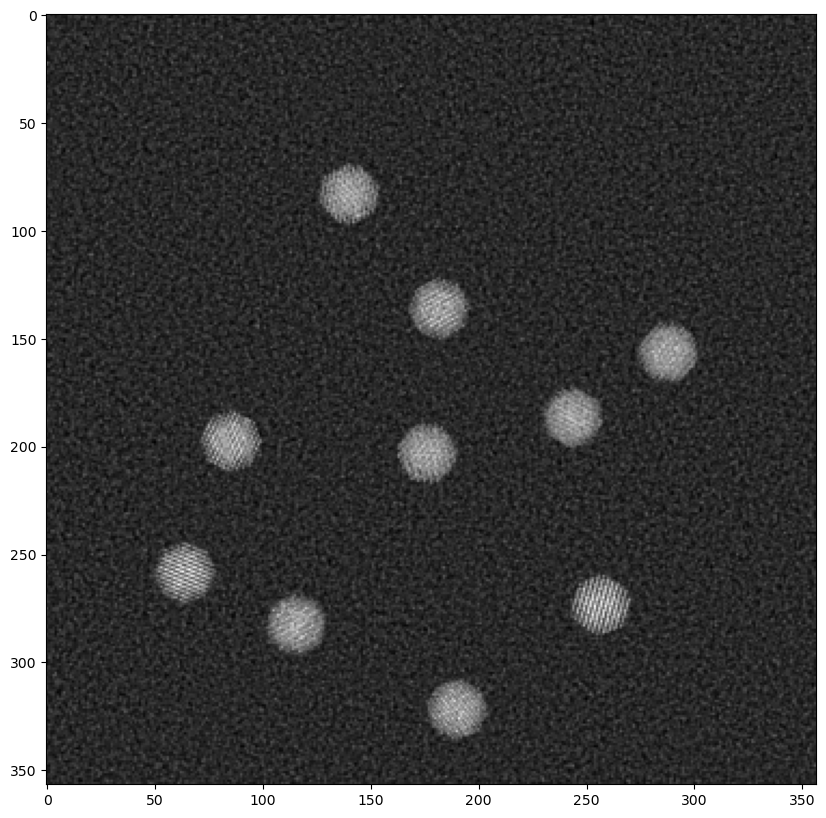

In [9]:
fig, ax = plt.subplots(figsize = (15, 10))
proj_pot = potential.array.sum(axis = 0).compute().get()
# ax.imshow(proj_pot, cmap = 'gray')
ax.imshow(proj_potential_normalized, cmap = 'gray')

# Segmenting

Image shape: (357, 357, 3)
Image dtype: uint8
Image range: [0, 255]


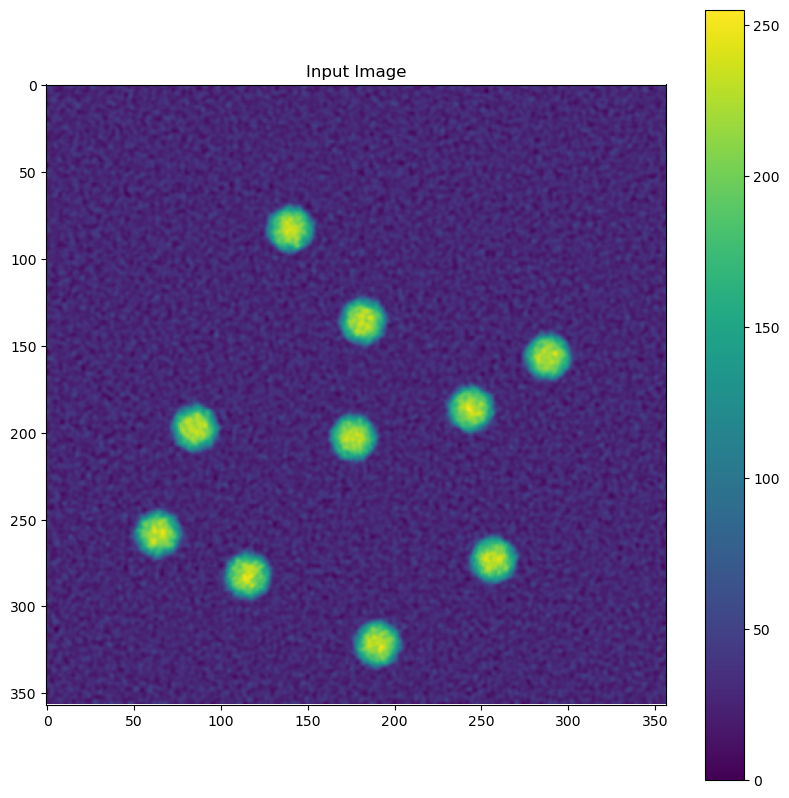

Generating masks...
Error in mask generation: index 2 is out of bounds for dimension 1 with size 0
SAM failed to generate masks. Using simple thresholding.


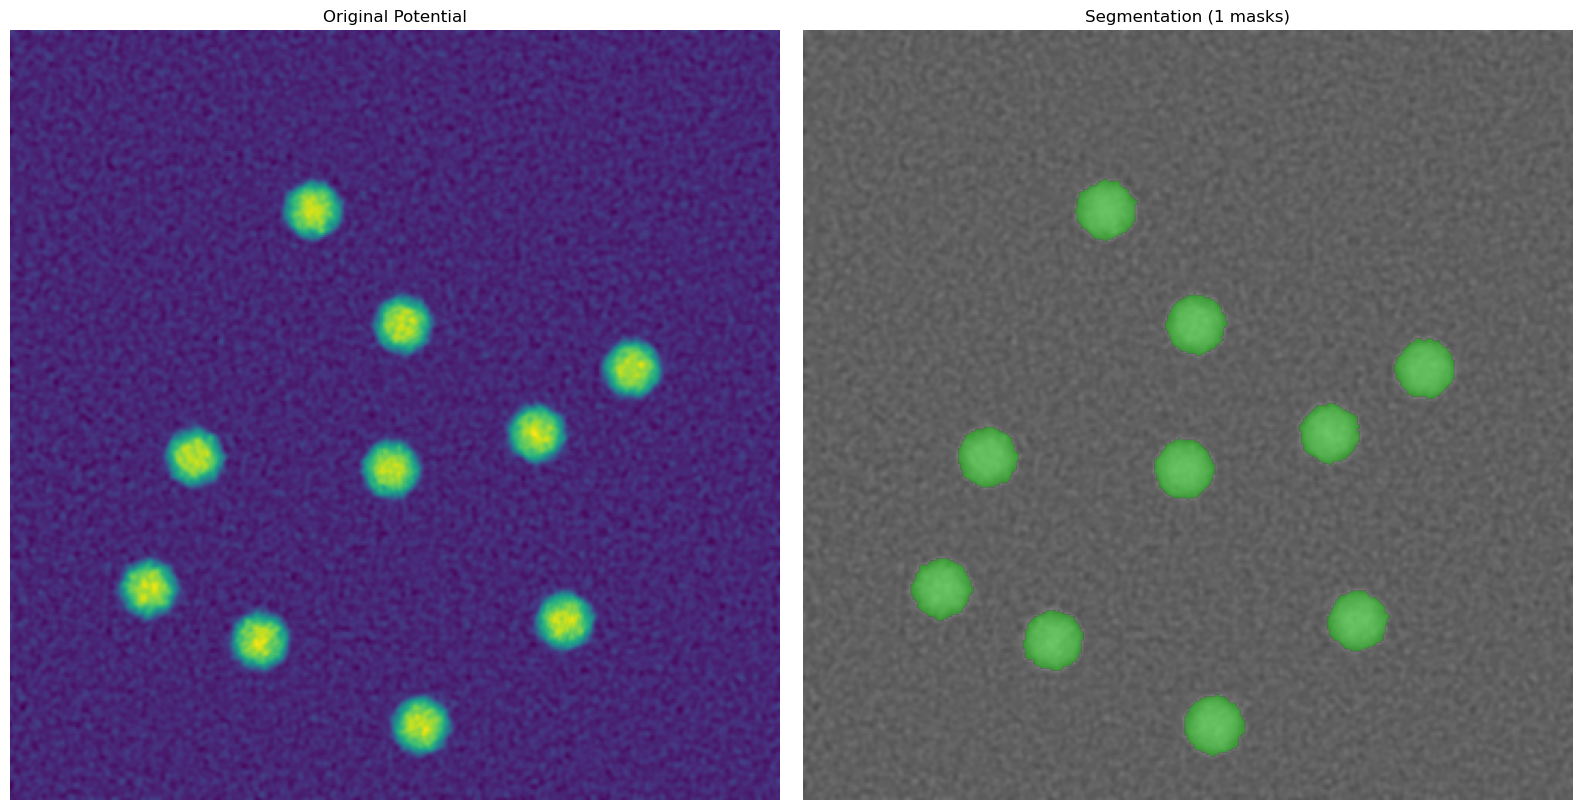

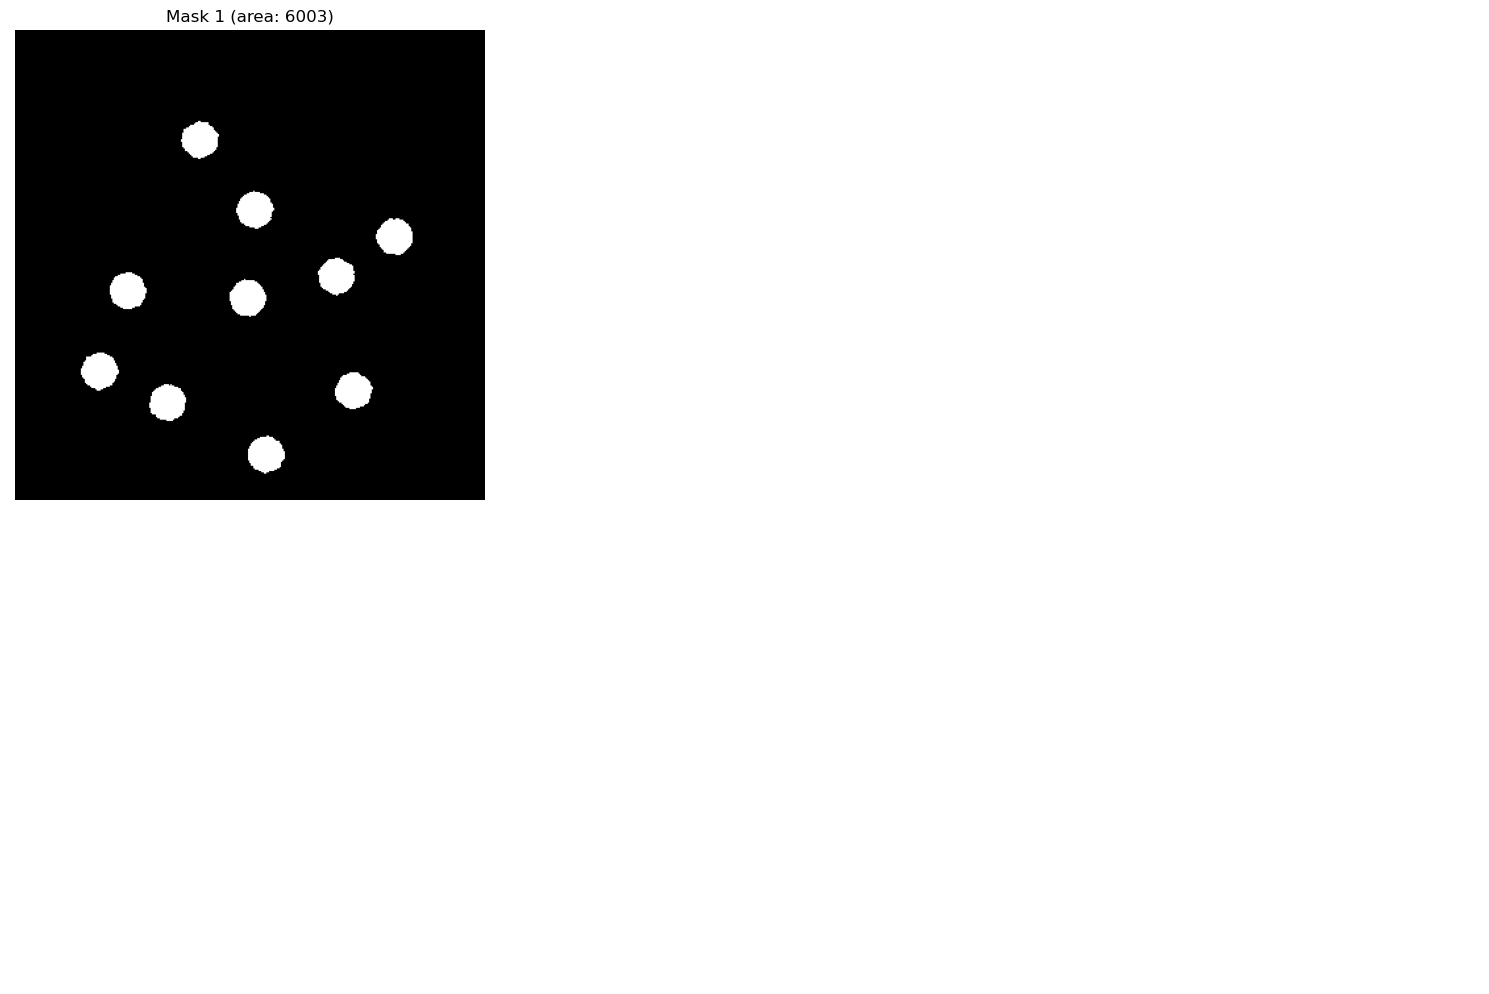

Number of labeled features: 10
Number of features after filtering: 10


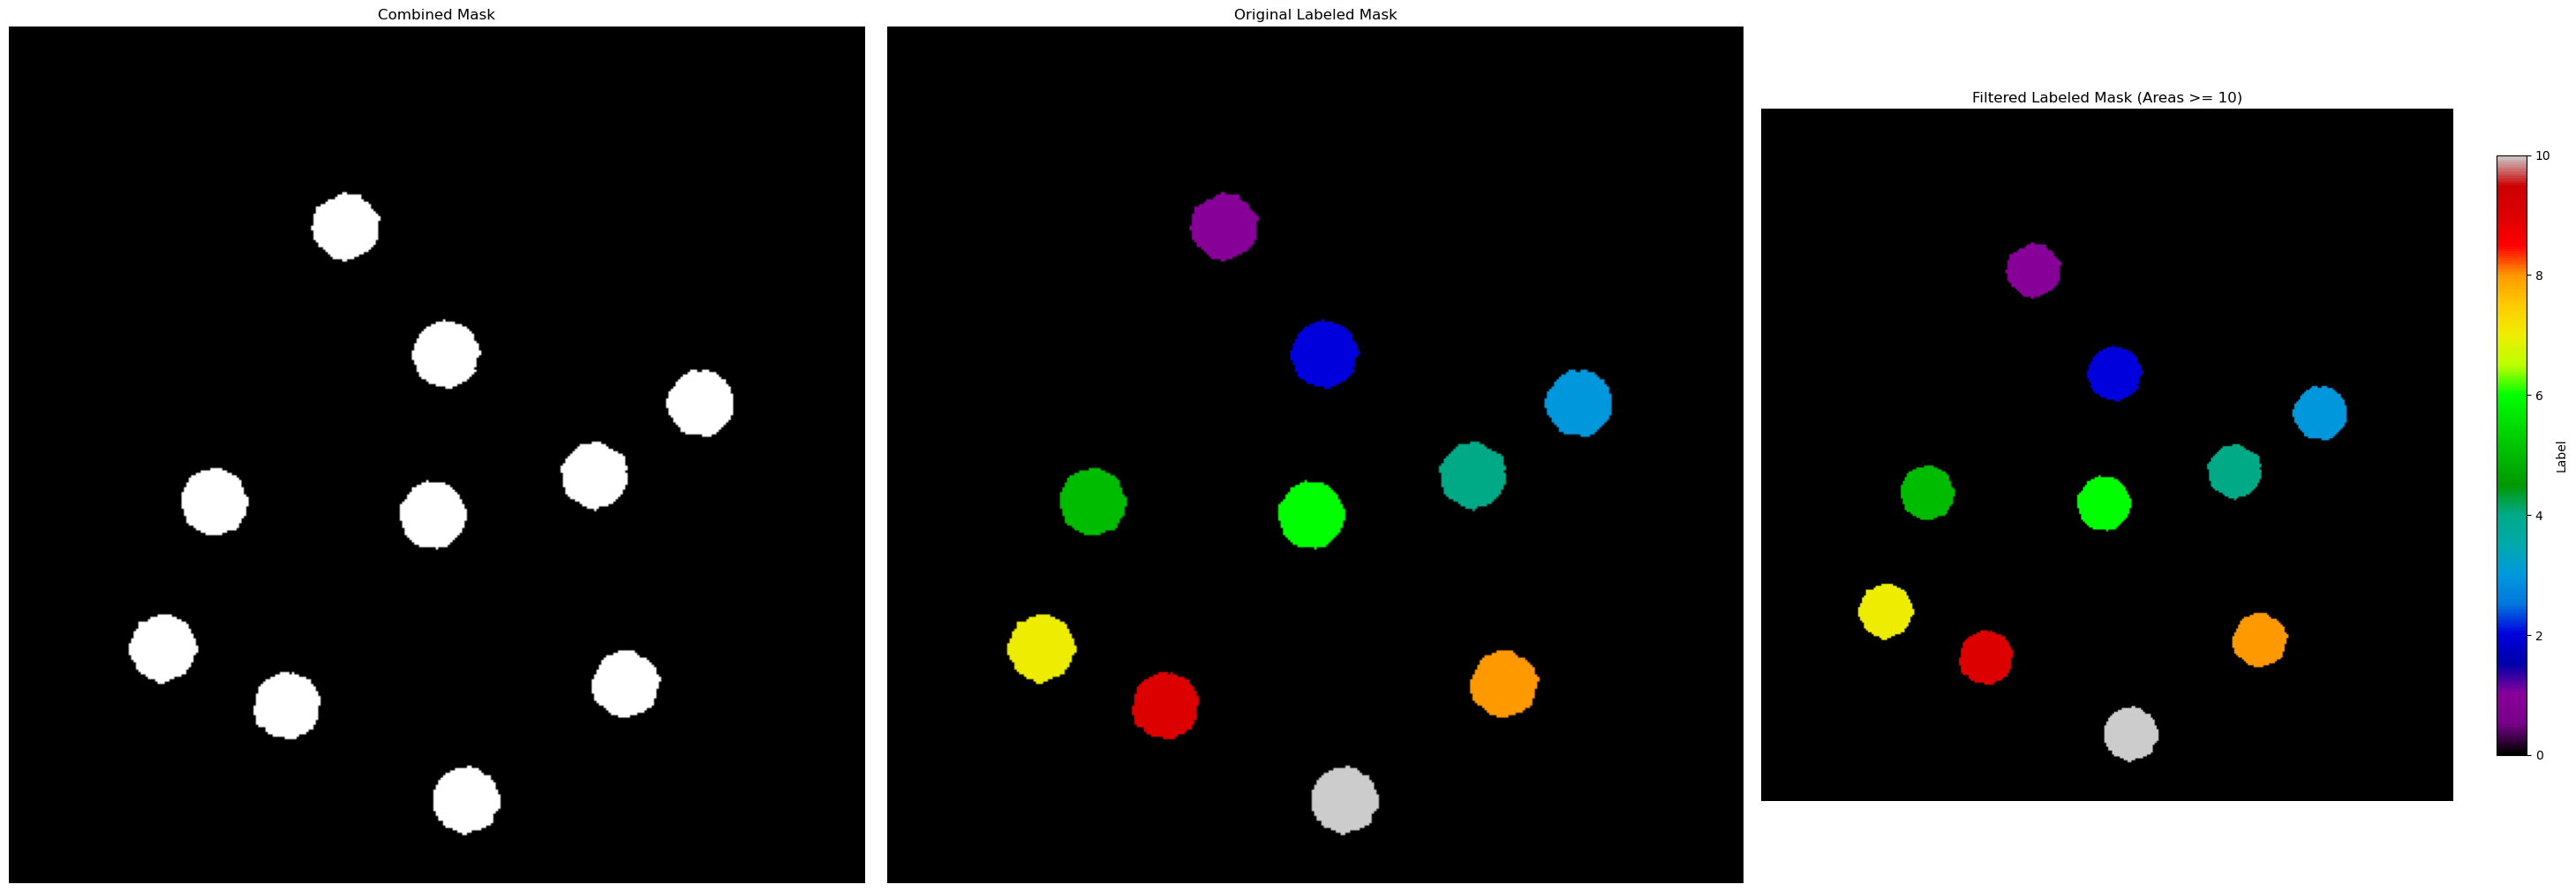

Filtered labeled mask shape: (357, 357)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10]
Label: 1
  Area: 598.0
  Centroid: (82.97324414715719, 140.02341137123747)
  Bounding box: (69, 126, 98, 155)
---
Label: 2
  Area: 602.0
  Centroid: (136.1295681063123, 181.79900332225913)
  Bounding box: (122, 168, 151, 197)
---
Label: 3
  Area: 597.0
  Centroid: (156.49916247906197, 287.96817420435514)
  Bounding box: (143, 274, 171, 302)
---
Label: 4
  Area: 592.0
  Centroid: (186.5793918918919, 243.77871621621622)
  Bounding box: (173, 230, 202, 258)
---
Label: 5
  Area: 604.0
  Centroid: (197.62417218543047, 85.24172185430463)
  Bounding box: (184, 72, 212, 100)
---
Label: 6
  Area: 601.0
  Centroid: (203.12811980033277, 176.33943427620633)
  Bounding box: (189, 163, 218, 191)
---
Label: 7
  Area: 606.0
  Centroid: (258.5693069306931, 63.82838283828383)
  Bounding box: (245, 50, 274, 79)
---
Label: 8
  Area: 601.0
  Centroid: (273.53910149750413, 256.69384359401)
  Bounding box: (260, 243, 28

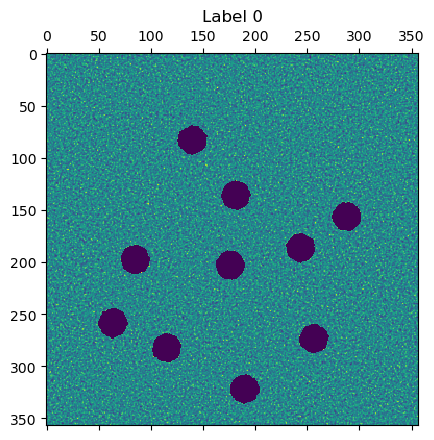

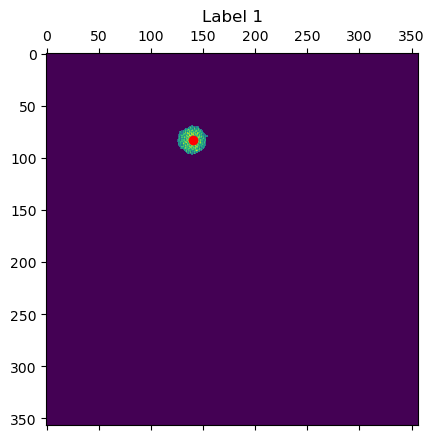

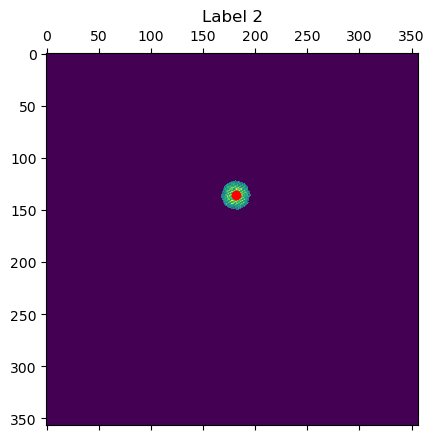

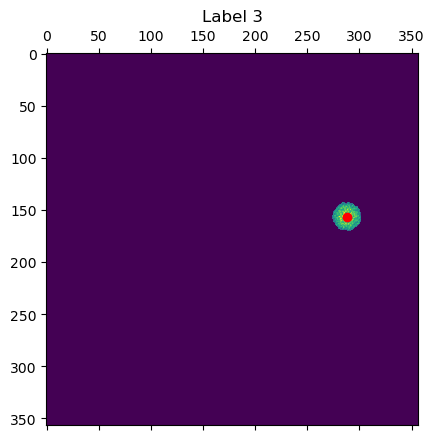

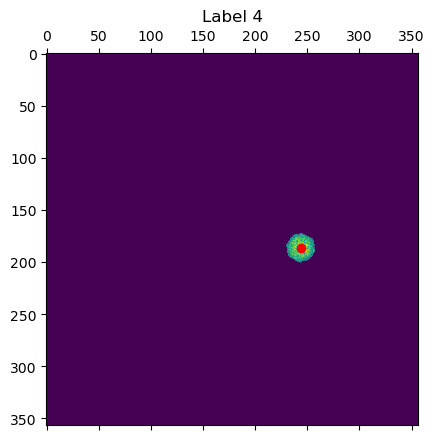

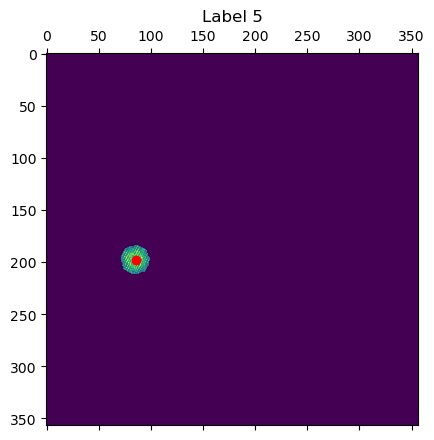

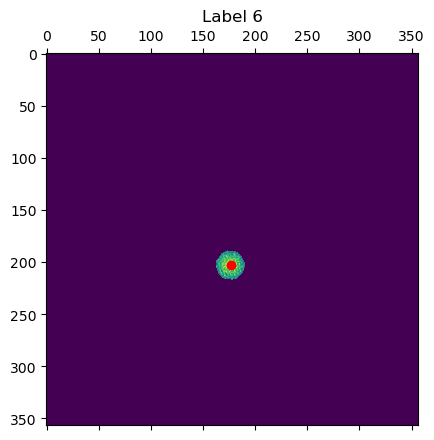

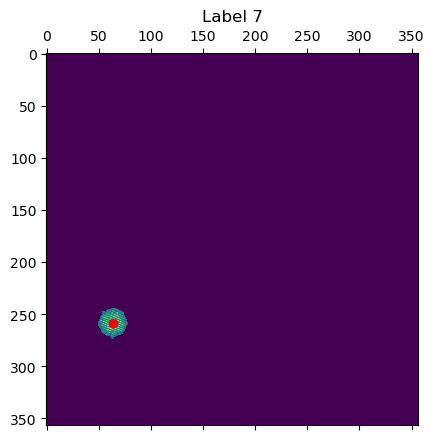

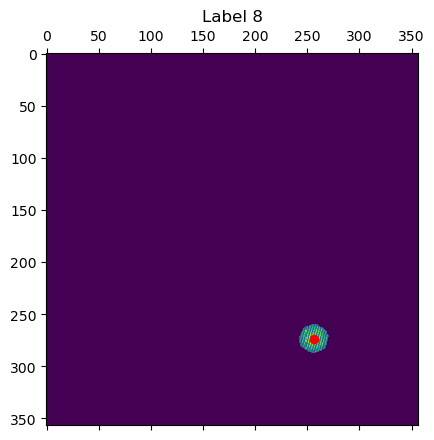

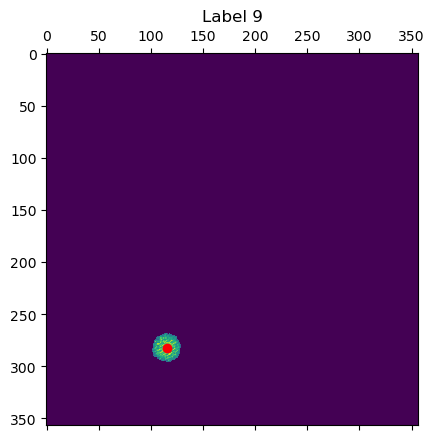

In [65]:
segmentor = Segmentor()
filtered_labeled_mask, com_list = segmentor.segment_image(potential)

In [66]:
filtered_labeled_mask, com = segmentor.segment_image(potential, show_plots=False)

Error in mask generation: index 2 is out of bounds for dimension 1 with size 0
SAM failed to generate masks. Using simple thresholding.


In [67]:
com

[array([ 82.99937, 140.03712], dtype=float32),
 array([136.10645, 181.78897], dtype=float32),
 array([156.5125, 288.036 ], dtype=float32),
 array([186.5843 , 243.77356], dtype=float32),
 array([197.58449 ,  85.236115], dtype=float32),
 array([203.12547, 176.25949], dtype=float32),
 array([258.50623 ,  63.874157], dtype=float32),
 array([273.47772, 256.7405 ], dtype=float32),
 array([282.5637, 115.4946], dtype=float32)]